In [3]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G,k,m_p,sigma
from scipy.integrate import simpson

# define constants
AU=1.495978707e11
MSUN=1.98847e30
RSUN=6.957e8
LSUN=3.828e26
YEAR=365.25*24*3600
MU=2.3
MH=m_p
PI=np.pi

# set plotting parameters
plt.rcParams['figure.figsize']=(7,5)
plt.rcParams['font.size']=12
plt.rcParams['axes.grid']=True
plt.rcParams['image.cmap']='inferno'

# define disk parameters
MSTAR=0.75
RSTAR=1.0888
LSTAR=0.242
TEFF=4000.0
RIN=4.5784
ROUT=192.95
NR=500
NZ=300
RC=48.0
GAMMA=1.5181
MDISK=0.0448
T0=150.0
R0=1.0
BETA=1.2121
Q=3.0-2.0*BETA

# define unit conversion functions
def au_to_m(x): return x*AU
def m_to_au(x): return x/AU
def msun_to_kg(x): return x*MSUN

# convert disk parameters to SI units
RIN_SI=au_to_m(RIN)
ROUT_SI=au_to_m(ROUT)
RC_SI=au_to_m(RC)
MDISK_SI=msun_to_kg(MDISK)
MSTAR_SI=msun_to_kg(MSTAR)

# define surface density profile function
def sigma_shape(R):
     x=R/RC_SI
     return x**(-GAMMA)*np.exp(-(x)**(2.0-GAMMA))

# compute normalization constant for surface density
R_int=np.logspace(np.log10(RIN_SI),np.log10(ROUT_SI),3000)
integrand=sigma_shape(R_int)*R_int
I=simpson(integrand,x=R_int)
SIGMA_C=MDISK_SI/(2.0*PI*I)

# define surface density function
def Sigma(R): 
    return SIGMA_C*sigma_shape(R)

# radial grid 
R=np.logspace(np.log10(RIN_SI),np.log10(ROUT_SI),NR)
R_AU=m_to_au(R)

# define temperature profile function
def Temperature(R): 
    return np.maximum(T0*(R/au_to_m(R0))**(-Q),0)
T=Temperature(R)

# compute disk properties
OMEGA=np.sqrt(G*MSTAR_SI/R**3)
VKEP=np.sqrt(G*MSTAR_SI/R)
CS=np.sqrt(k*T/(MU*MH))
H=CS/OMEGA
H_AU=m_to_au(H)
ASPECT_RATIO=H/R

# Vertical grid
ETA=np.linspace(-5.0,5.0,NZ)
ZZ=H[:,None]*ETA[None,:]
ZZ_AU=m_to_au(ZZ)
RR=np.repeat(R[:,None],NZ,axis=1)
RR_AU=m_to_au(RR)

# compute density profile
SIGMA=Sigma(R)
SIGMA_2D=SIGMA[:,None]
H_2D=H[:,None]
RHO=(SIGMA_2D/(np.sqrt(2.0*PI)*H_2D))*np.exp(-0.5*(ZZ/H_2D)**2)

MID=NZ//2
RHOMID=RHO[:,MID]
PMID=RHOMID*CS**2
DPDR=np.gradient(PMID,R)

ZR=ZZ_AU[:,MID:]/RR_AU[:,MID:]
LOGRHO=np.log10(RHO[:,MID:])


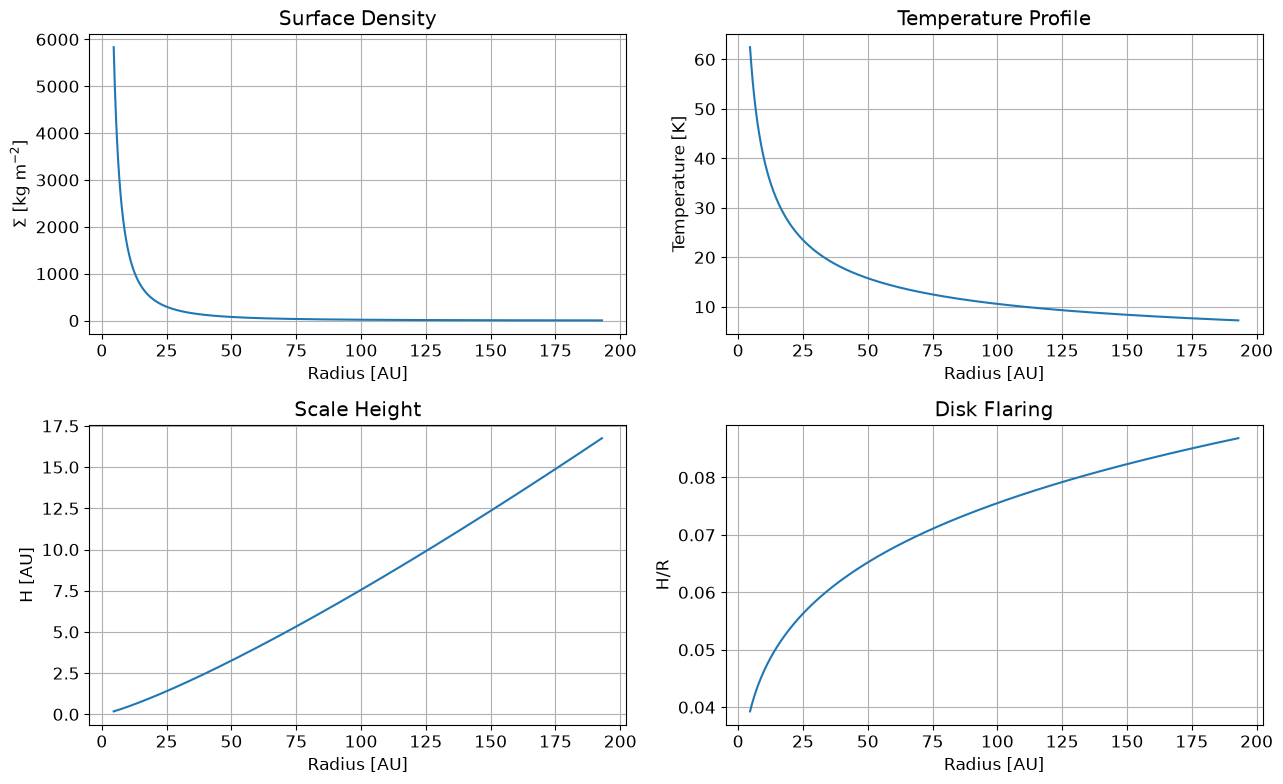

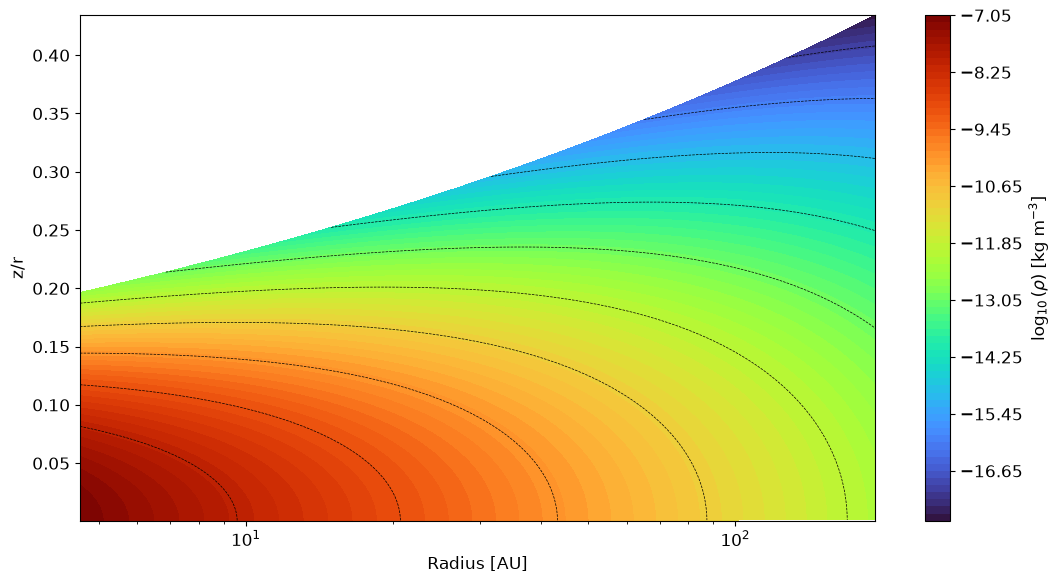

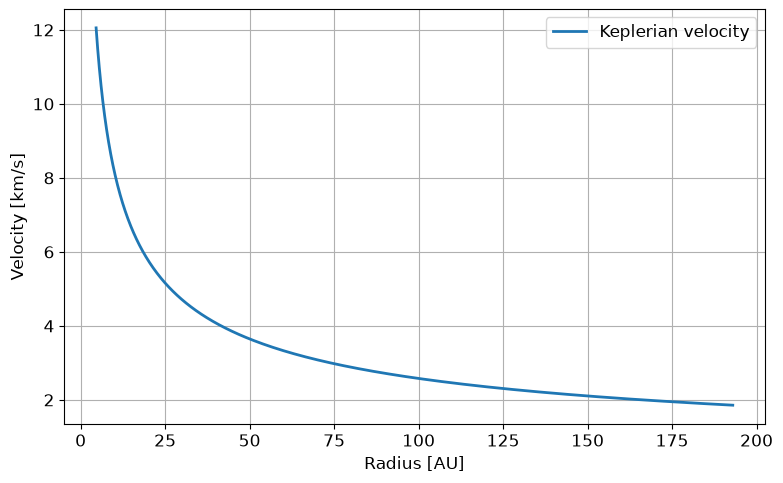

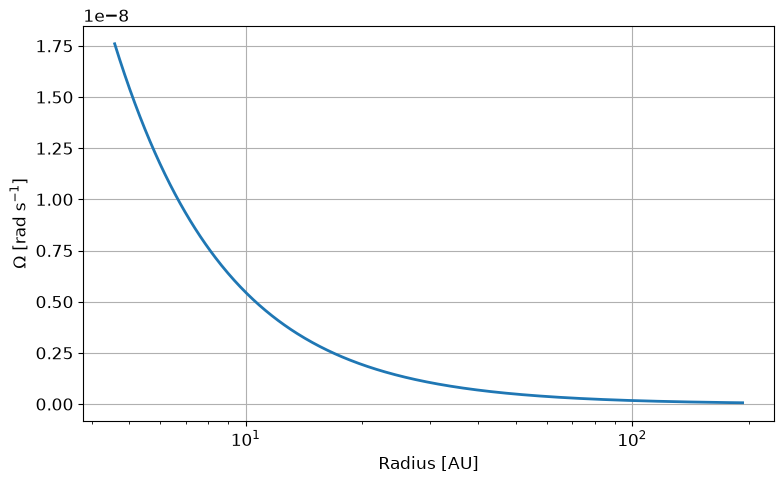

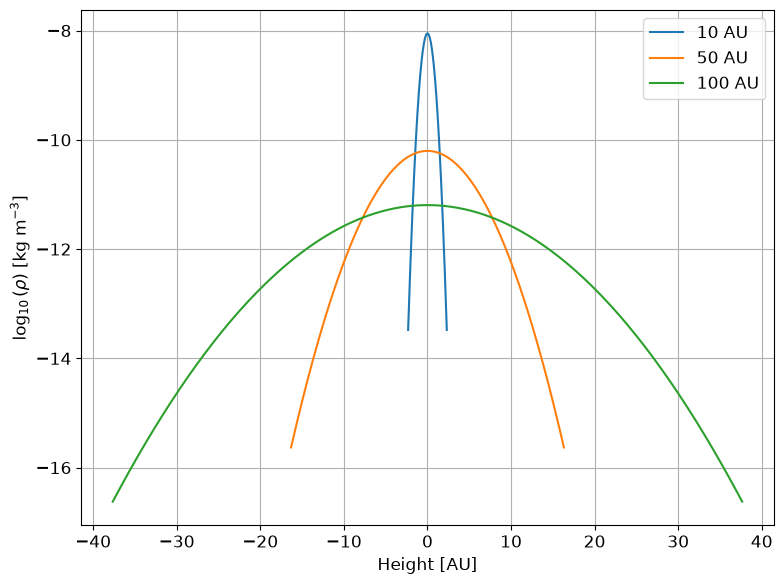

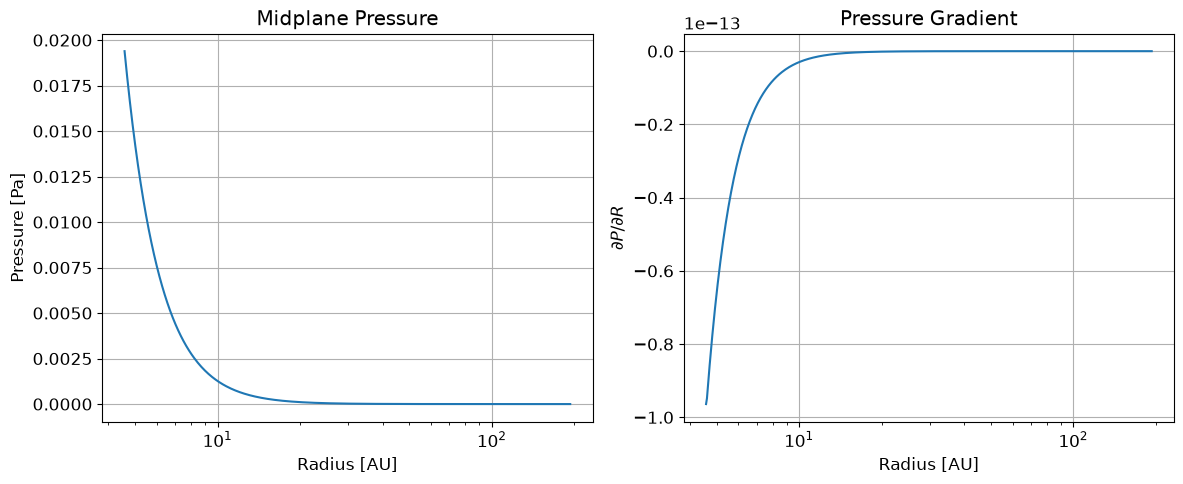

In [4]:
# plot results

fig,ax=plt.subplots(2,2,figsize=(13,8))
ax[0,0].plot(R_AU,SIGMA);ax[0,0].set_xlabel("Radius [AU]");ax[0,0].set_ylabel(r"$\Sigma$ [kg m$^{-2}$]");ax[0,0].set_title("Surface Density")
ax[0,1].plot(R_AU,T);ax[0,1].set_xlabel("Radius [AU]");ax[0,1].set_ylabel("Temperature [K]");ax[0,1].set_title("Temperature Profile")
ax[1,0].plot(R_AU,H_AU);ax[1,0].set_xlabel("Radius [AU]");ax[1,0].set_ylabel("H [AU]");ax[1,0].set_title("Scale Height")
ax[1,1].plot(R_AU,ASPECT_RATIO);ax[1,1].set_xlabel("Radius [AU]");ax[1,1].set_ylabel("H/R");ax[1,1].set_title("Disk Flaring")
plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(11,6))
cf=ax.contourf(RR_AU[:,MID:],ZR,LOGRHO,levels=100,cmap='turbo')
cs=ax.contour(RR_AU[:,MID:],ZR,LOGRHO,levels=np.arange(-18,-7,1),colors='k',linewidths=0.5)
ax.grid(False);plt.colorbar(cf,label=r'$\log_{10}(\rho)$ [kg m$^{-3}$]');ax.set_xscale('log');ax.set_xlabel('Radius [AU]');ax.set_ylabel('z/r');plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(8,5));ax.plot(R_AU,VKEP/1000,lw=2,label='Keplerian velocity');ax.set_xlabel('Radius [AU]');ax.set_ylabel('Velocity [km/s]');ax.grid(True);ax.legend();plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(8,5));ax.plot(R_AU,OMEGA,lw=2);ax.set_xscale('log');ax.set_xlabel('Radius [AU]');ax.set_ylabel(r'$\Omega$ [rad s$^{-1}$]');plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(8,6));radii=[10,50,100]
for r0 in radii:
    idx=np.argmin(np.abs(R_AU-r0))
    ax.plot(ZZ_AU[idx],np.log10(RHO[idx]),label=f'{R_AU[idx]:.0f} AU')
ax.set_xlabel("Height [AU]");ax.set_ylabel(r'$\log_{10}(\rho)$ [kg m$^{-3}$]');ax.legend();plt.tight_layout();plt.show()
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].plot(R_AU,PMID);ax[0].set_xscale('log');ax[0].set_xlabel('Radius [AU]');ax[0].set_ylabel('Pressure [Pa]');ax[0].set_title('Midplane Pressure')
ax[1].plot(R_AU,DPDR);ax[1].set_xscale('log');ax[1].set_xlabel('Radius [AU]');ax[1].set_ylabel(r'$\partial P/\partial R$');ax[1].set_title('Pressure Gradient')
plt.tight_layout();plt.show()
